# ITCS 6169/8169 — Computer Vision
## Assignment 1: The CNN Challenge
**Due: September 25, 2026 at 11:59 PM EDT**

---

In this assignment, you will build and train a convolutional neural network (CNN) for **16-class scene recognition** using a small dataset of **2,400 training images**.

This notebook is intentionally only a **starter baseline**. It provides a clean training pipeline and a deliberately simple CNN. Your task is to improve the system through informed decisions about architecture, optimization, augmentation, regularization, model selection, and training strategy.

### 2026 workflow: AI is your pair programmer
Use of an AI coding assistant (e.g., ChatGPT, Codex, GitHub Copilot, Claude Code, Gemini, Cursor) is **required**. You may use AI to help implement, debug, refactor, explain, or suggest experiments. However, **you are responsible for the scientific decisions and for verifying all generated code**.

Your final GitHub repository must include an `AI_USAGE.md` file describing representative AI-assisted tasks, at least one incorrect/ineffective AI suggestion, how you verified or corrected it, and one important decision that you made yourself.

### Important model restriction
The primary classifier for Assignment 1 must be a **CNN**. Do **not** use CLIP, DINO/DINOv2, VLM APIs, Vision Transformers as the primary model, or other foundation-model embeddings for your main submission. Pretrained CNNs are allowed if clearly documented.

### Google Colab
Google Colab is recommended, but not required. If using Colab, enable a GPU through **Runtime → Change runtime type → GPU**. You may also use the Educational Cluster or another resource for which you have authorized access.

In [1]:
# Core imports
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch_directml # to allow for AMD gpu usage

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.4.1+cpu
CUDA available: False


## 1. Set your working directory

Download the assignment dataset from the link provided in the assignment handout and organize it so that the notebook can find:

```text
data/
  train/
    class_1/
    ...
  test/
    class_1/
    ...
```

If you use Google Drive, change `PROJECT_ROOT` below to your assignment folder. **Do not hard-code a TA/instructor solution path.**

In [2]:
# CHANGE THIS PATH to your own assignment directory.
# Example for Colab + Google Drive:
# PROJECT_ROOT = Path('/content/gdrive/MyDrive/ITCS_6169_8169/assignment1')

PROJECT_ROOT = Path('.')
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'

print('Project root:', PROJECT_ROOT.resolve())
print('Training data:', TRAIN_ROOT)
print('Testing data:', TEST_ROOT)

Project root: D:\School\13 - Fall 2026\ITCS 6169\assignment1
Training data: data\train
Testing data: data\test


## 2. Reproducibility and device

A fixed seed makes the starter result easier to reproduce. Exact GPU reproducibility is not always guaranteed across hardware/software versions, so report your environment and seed in the final repository.

In [3]:
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch_directml.device() # Set device to AMD GPU via DirectML
print('Using device:', device)

Using device: privateuseone:0


## 3. Loading and preprocessing the data

The starter baseline converts images to grayscale and resizes them to $64\times64$. This is **not necessarily a good final choice**. You should decide whether color, resolution, normalization, and augmentation should be changed.

We split the provided training data into **training and validation sets**. Use the validation set for architecture/hyperparameter decisions. **Do not repeatedly tune on the test set.** The test set should be used for the final evaluation of a selected model.

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 128
VAL_FRACTION = 0.20

# Mixup helper function
def mixup_data(x, y, alpha=0.2):
    '''Returns mixed inputs, pairs of targets, and lambda.'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Define the corresponding loss function
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def random_grayscale_rgb(img):
    # Augment only on training; validation/test should stay clean.
    if random.random() < 0.2:
        gray = img.convert("L")
        return gray.convert("RGB")
    return img

# Training augmentation: random transforms only here.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.Lambda(random_grayscale_rgb),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Validation/test preprocessing: no randomness.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

# Load base dataset once so we can split by index.
base_train_dataset = datasets.ImageFolder(TRAIN_ROOT)
class_names = base_train_dataset.classes
num_classes = len(class_names)

val_size = int(round(len(base_train_dataset) * VAL_FRACTION))
train_size = len(base_train_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset = random_split(
    base_train_dataset, [train_size, val_size], generator=generator
)

train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, eval_transform)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=torch.cuda.is_available())

print(f'Classes ({num_classes}): {class_names}')
print(f'Total training images: {len(base_train_dataset)}')
print(f'Test images: {len(test_dataset)}')
print(f'Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Total training images: 2400
Test images: 400
Train: 1920 | Validation: 480 | Test: 400


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6021352].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7589979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.46476585..1.6355041].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5418272..1.6544228].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.279695].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48189062..1.5411329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..

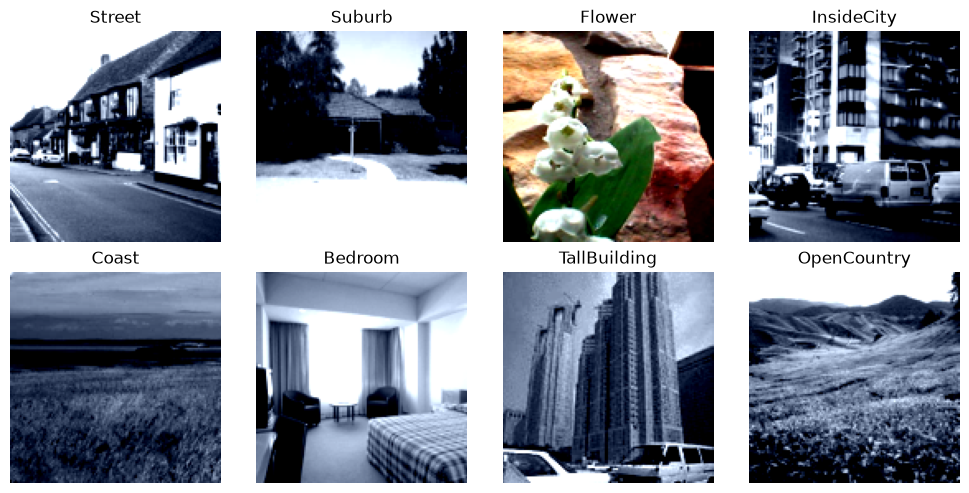

In [5]:
# Visualize a few training examples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    # Undo normalization for both grayscale (C=1) and RGB (C=3)
    if image.shape[0] == 1:
        image = image[0] * 0.5 + 0.5
        ax.imshow(image.numpy(), cmap='gray')
    else:
        image = image.permute(1, 2, 0)  # HWC
        image = image * 0.5 + 0.5
        ax.imshow(image.numpy())
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Training a CNN from scratch

Gone are the days when hand-designed features were the default solution. We will start with end-to-end learning and train a CNN directly for 16-way classification.

The architecture below is deliberately weak and simple. **Do not treat it as a recommended architecture.** It exists only to verify that the pipeline works and to give you a baseline to beat.

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(residual)

        out = out + residual
        out = self.relu(out)
        return out

In [7]:
class TNet(nn.Module):
    """A deliberately small CNN starter baseline."""
    def __init__(self, num_classes=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            
            ResidualBlock(16, 32, stride=2),
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 128, stride=2),
            
            # nn.MaxPool2d(kernel_size=2, stride=2),
            
            # nn.Conv2d(16, 32, kernel_size=3, padding=1),
            # nn.BatchNorm2d(32),
            # nn.ReLU(inplace=True),
            # nn.MaxPool2d(kernel_size=2, stride=2),
            
            # nn.Conv2d(32, 64, kernel_size=3, padding=1),
            # nn.BatchNorm2d(64),
            # nn.ReLU(inplace=True),
            # nn.MaxPool2d(kernel_size=2, stride=2),
            
            # nn.Conv2d(64, 128, kernel_size=3, padding=1),
            # nn.BatchNorm2d(128),
            # nn.ReLU(inplace=True),
            # nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TNet(num_classes=num_classes)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

TNet(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ResidualBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential(
        (0): Conv2d(16, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (4): ResidualBlock(
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=

## 5. Training and evaluation utilities

The training loop below selects the checkpoint with the **best validation accuracy**. This is a much better experimental practice than evaluating the test set after every epoch.

You are welcome to rewrite this code. For example, you may add a scheduler, mixed precision, early stopping, checkpointing, experiment tracking, or richer metrics. If AI helps you implement such changes, verify the implementation and document representative usage in `AI_USAGE.md`.

In [8]:
# @torch.inference_mode()
@torch.no_grad() # gemini solution for directml
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, epochs=20, device=device, mixup_alpha=0.0):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            if mixup_alpha > 0:
                mixed_images, labels_a, labels_b, lam = mixup_data(
                    images, labels, alpha=mixup_alpha
                )
                logits = model(mixed_images)
                loss = mixup_criterion(criterion, logits, labels_a, labels_b, lam)
            else:
                logits = model(images)
                loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_seen += labels.size(0)

        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
              f'val acc {val_acc:.4f} | {elapsed:.1f}s')

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f}')
    return model, history

In [9]:
# Train the model
epochs = 50
set_random_seed(SEED)
model = TNet(num_classes=num_classes)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

model, history = train_model(
    model, train_loader, val_loader, optimizer, epochs=epochs, device=device,
    mixup_alpha=0.2
)

d:\School\13 - Fall 2026\ITCS 6169\assignment1\.venv\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch 01/50 | train loss 2.6671 | val loss 2.7292 | val acc 0.1062 | 11.6s
Epoch 02/50 | train loss 2.5514 | val loss 2.6251 | val acc 0.1333 | 18.0s
Epoch 03/50 | train loss 2.3484 | val loss 2.2912 | val acc 0.2583 | 23.7s
Epoch 04/50 | train loss 2.2562 | val loss 2.1562 | val acc 0.2979 | 29.3s
Epoch 05/50 | train loss 2.1527 | val loss 2.0632 | val acc 0.3583 | 34.8s
Epoch 06/50 | train loss 1.9666 | val loss 1.9347 | val acc 0.3604 | 40.9s
Epoch 07/50 | train loss 1.8740 | val loss 1.9406 | val acc 0.3042 | 46.9s
Epoch 08/50 | train loss 1.8141 | val loss 1.9675 | val acc 0.3208 | 52.7s
Epoch 09/50 | train loss 1.7435 | val loss 1.6059 | val acc 0.4625 | 58.5s
Epoch 10/50 | train loss 1.6170 | val loss 1.3721 | val acc 0.5479 | 64.3s
Epoch 11/50 | train loss 1.7274 | val loss 1.3277 | val acc 0.5854 | 70.3s
Epoch 12/50 | train loss 1.6684 | val loss 1.3752 | val acc 0.5458 | 76.2s
Epoch 13/50 | train loss 1.5873 | val loss 1.2107 | val acc 0.6208 | 81.8s
Epoch 14/50 | train loss 

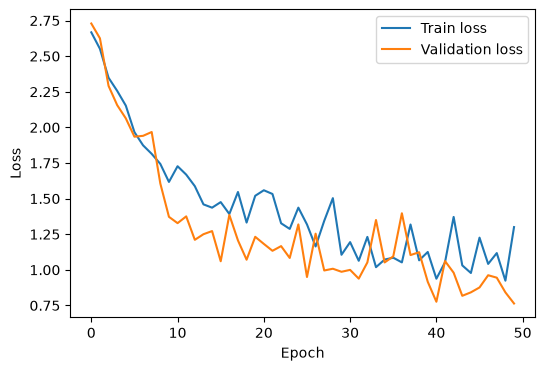

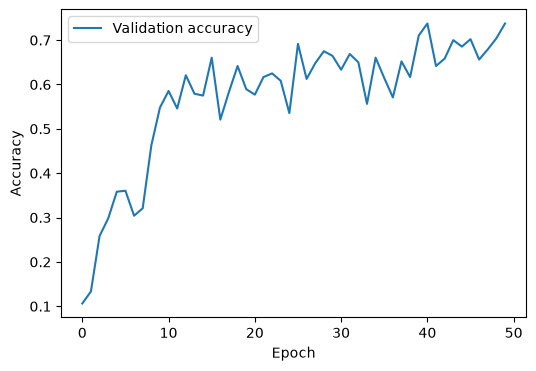

In [10]:
# Plot the starter training history.
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 6. Your turn: beat the baseline

This simple model should only be treated as a sanity check. Your objective is to substantially improve it.

Rather than asking an AI tool to ``make the accuracy higher,'' formulate hypotheses yourself. Examples of useful questions include whether the model is overfitting, whether color matters, whether stronger augmentation helps, whether a different CNN family is more appropriate, whether pretrained CNN features transfer well, or whether optimization/regularization is limiting performance.

For each important experiment, write down:

| Experiment | What changed? | Why did you try it? | Validation accuracy | What did you learn? |
|---|---|---|---:|---|
| Baseline | Starter TNet | Sanity check | 0.4667 | Model is overfitting after 11 epochs |
| Experiment 1 | Adjusted pipeline to work with RGB images | Seems bad to grayscale all images and I want to try that as an augmentation later | 0.5000 | Not grayscaling all images is better. Model still overfits though |
| Experiment 2 | Added another convolution layer | Just curious, although it'll probably make overfitting even worse | 0.5104 | Overfitting was unchanged but accuracy improved. Will keep this as a baseline for other experiments for a little while |
| Experiment 3 | Added weight decay, dropout, and another linear layer in the classifier | AI-suggested solutions for overfitting | 0.5312 | Didn't seem to help with overfitting, but did increase accuracy. Going to move on to some of the ideas I had previously and revisit the overfitting issue later |
| Experiment 4 | Resized images to 128x128 | 64x64 seems too low, and runtime isn't a concern yet | 0.4854 | Not much. I should probably record highest validation accuracy (.5146) and not final, since it tends to fluctuate due to the overfitting |
| Experiment 5 | Added data augmentations: Horizontal flip and color jitter. Also changed normalization statistics | Wanted to do data augmentation, asked AI for ideas. Apparently these noramlization statistics are standard defaults for this field | 0.5312 (starting to use best instead of final) | Took much longer to train and did not reach peak validation accuracy in nearly as few epochs, which I think is a good sign. Overfitting also isn't nearly as bad
| Experiment 6 | Added batch normalization after both convolutional layers | AI-recommended solution for overfitting that I didn't try earlier | 0.4958 | Seems to have solved overfitting, as train and validation loss have stopped diverging. Looks like the loss would continue going down with more training |
| Experiment 7 | Increased epochs from 20 to 50 | Wanted to see how long until accuracy stops increasing since it looked like overfitting was solved | 0.5875 | Overfitting starts, funnily enough, right around epoch 20 |
| Experiment 8 | Reverted back to 1 convolutional layer | The increase in depth wasn't particularly motivated and also didn't change things severely, so I got curious again to see if it had done anything | 0.3375 | I'm assuming that at the beginning, the model was so simple that no particular change really mattered, and accuracy was always staying around 50% as a result. Now that there are some changes that move the model from randomly predicting to actually learning somewhat, the importance of depth has emerged. At least, that's my theory. |
| Experiment 9 | Tried out 3 convolutional layers | Wondering if increasing the depth would be as drastic a change as decreasing | 0.6646 | Deeper seems good, but something extremely weird started happening with validation loss. It still tracks pretty closely with training loss, except it does so while wildly fluctuating. My guess is that the learning rate is too high. |
| Experiment 10 | Changed learning rate from 0.002 to 0.0001 | See earlier experiment | 0.4562 | Model didn't have time to converge. Overshot the decrease |
| Experiment 11 | Made transforms stop applying to validation dataset | I didn't want to bother doing this earlier since it looked like it would be annoying but I thought it might help with the fluctuating | 0.6750 | It might've helped a little bit, but it's still really bad, even on 0.0002 LR |
| Experiment 12 | Added another convolutional layer | Wanted to see if the fluctuating would get even worse, and also because the last deepening was good for accuracy | 0.7146 | Accuracy got better, still fluctuates wildly, and started overfitting a little bit again |
| Experiment 13 | Residual connections | I wanted to try these from the start. Model's deep enough now to | 0.7146 | The overfitting and fluctuating is even worse now, even though the accuracy's the same. I don't understand enough to know why |
| Experiment 14 | Implemented MixUp | This was mentioned as being effective in class multiple times | 0.7375 | It's pretty effective |  
| Final model | | | | |

**Do not use the test set to choose among these experiments.**

In [11]:
# FINAL TEST EVALUATION
# Run this only after you have selected your final model using validation results.
# Replace `model` with your final selected model/checkpoint.

test_loss, test_acc = evaluate(model, test_loader, device)
print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_acc:.4f}')

Final test loss: 0.8382
Final test accuracy: 0.7275


## 7. AI-assisted development checkpoint

Before submission, create `AI_USAGE.md` in your GitHub repository. You do **not** need to provide every prompt. Include:

1. the AI coding tool(s) you used;
2. 3--5 representative ways AI assisted you;
3. at least one AI suggestion that was incorrect, ineffective, or questionable;
4. how you tested, verified, corrected, or rejected that suggestion; and
5. one important architecture/experimental decision that **you** made.

A good entry describes the engineering/research interaction rather than saying only, ``I used ChatGPT to write code.''

### A useful habit
When AI generates code, ask yourself before running it:
- What do I expect this code to do?
- What assumption is it making about tensor shape/data/model behavior?
- How will I know if it is wrong?
- What experiment would distinguish a real improvement from noise?

## 8. GitHub and submission requirements

All assignment code must be maintained in **GitHub** (not GitLab). Your repository should contain a meaningful commit history and, at minimum:

```text
README.md
AI_USAGE.md
training / model code
inference or evaluation code
requirements.txt or environment information
final checkpoint or a link to it
reproduction instructions
```

Do not create the entire repository as a single commit immediately before the deadline. Use Git throughout development as you would in a real research or engineering project.

Your final submission is a **maximum two-page PDF report** containing the working GitHub link. The report should clearly state your best result, validation/model-selection strategy, final recipe, important experiments, at least one failure analysis, and a brief AI+human reflection.

Friendly discussion and brainstorming are encouraged, but your implementation, experiments, report, and repository must be your own. Do not share code, checkpoints, detailed hyperparameters, or test predictions before the deadline.

The instructor may ask you to explain any important component of your submitted system. You are responsible for understanding all code in your final repository, including AI-generated code.

**Deadline: September 25, 2026 at 11:59 PM EDT.**

Good luck — and treat this as your first small computer vision research project of the semester.